In [27]:
import pandas as pd
import os
import glob

# Paths
brain_tumor_path = r"C:\Users\A\Desktop\Internship\EHR_Infosys\data\Data\brain_tumor"
ehr_csv_path = r"C:\Users\A\Desktop\Internship\EHR_Infosys\data\Data\cancer_diagnosis_data.csv"

# Load EHR dataset
ehr_df = pd.read_csv(ehr_csv_path)
print("EHR Dataset Loaded Successfully!")
print("Shape:", ehr_df.shape)
ehr_df.head()


EHR Dataset Loaded Successfully!
Shape: (20000, 9)


,Patient_ID,Age,Gender,Tumor_Size(cm),Tumor_Type,Biopsy_Result,Treatment,Response_to_Treatment,Survival_Status
0,c044501a-43ca-4a0c-8b8b-991439ba1b6a,52,Female,5.08,Benign,Positive,Surgery,No Response,Survived
1,b8900c4c-1232-4084-9432-5d02eba74d20,32,Female,0.80,Benign,Negative,Surgery,Complete Response,Survived
2,3004e2bc-8037-49cb-a542-d5612b73beab,70,Female,9.56,Benign,Positive,Radiation Therapy,Complete Response,Deceased
3,1df86af7-6745-4dea-b127-cbc9915079fc,21,Female,3.07,Malignant,Negative,Surgery,Partial Response,Survived
4,128e00c3-72e3-4031-a7f4-1165d7199cce,62,Male,7.17,Malignant,Positive,Radiation Therapy,Complete Response,Deceased


Total images found: 21672


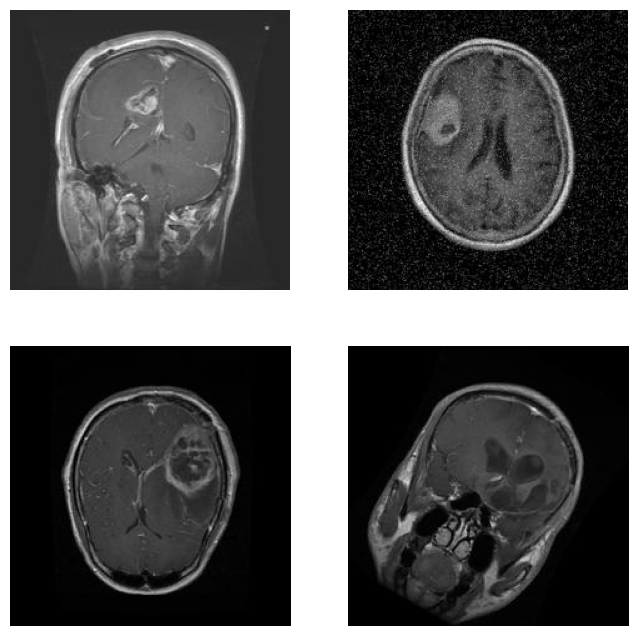

In [23]:
import matplotlib.pyplot as plt
import random
import cv2

# Collect image file paths
image_paths = []
for root, dirs, files in os.walk(brain_tumor_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_paths.append(os.path.join(root, file))

print(f"Total images found: {len(image_paths)}")

# Show a few random samples
samples = random.sample(image_paths, 4)
plt.figure(figsize=(8,8))
for i, path in enumerate(samples):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.show()


In [25]:
print("\nColumns:", ehr_df.columns.tolist())

# Drop duplicates and missing values
ehr_df = ehr_df.dropna().drop_duplicates()

# Convert all text to lowercase (for standardization)
for col in ehr_df.select_dtypes(include='object').columns:
    ehr_df[col] = ehr_df[col].str.lower().str.strip()

print("\nAfter cleaning:")
print(ehr_df.info())
ehr_df.head()


Columns: ['Patient_ID', 'Age', 'Gender', 'Tumor_Size(cm)', 'Tumor_Type', 'Biopsy_Result', 'Treatment', 'Response_to_Treatment', 'Survival_Status']

After cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             20000 non-null  object 
 1   Age                    20000 non-null  int64  
 2   Gender                 20000 non-null  object 
 3   Tumor_Size(cm)         20000 non-null  float64
 4   Tumor_Type             20000 non-null  object 
 5   Biopsy_Result          20000 non-null  object 
 6   Treatment              20000 non-null  object 
 7   Response_to_Treatment  20000 non-null  object 
 8   Survival_Status        20000 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.4+ MB
None


,Patient_ID,Age,Gender,Tumor_Size(cm),Tumor_Type,Biopsy_Result,Treatment,Response_to_Treatment,Survival_Status
0,c044501a-43ca-4a0c-8b8b-991439ba1b6a,52,female,5.08,benign,positive,surgery,no response,survived
1,b8900c4c-1232-4084-9432-5d02eba74d20,32,female,0.80,benign,negative,surgery,complete response,survived
2,3004e2bc-8037-49cb-a542-d5612b73beab,70,female,9.56,benign,positive,radiation therapy,complete response,deceased
3,1df86af7-6745-4dea-b127-cbc9915079fc,21,female,3.07,malignant,negative,surgery,partial response,survived
4,128e00c3-72e3-4031-a7f4-1165d7199cce,62,male,7.17,malignant,positive,radiation therapy,complete response,deceased


In [33]:
# === Load Brain Tumor image paths ===
image_paths = glob.glob(os.path.join(brain_tumor_path, "**", "*.jpg"), recursive=True)
print("✅ Images found:", len(image_paths))
output_path = r"C:\Users\A\Desktop\Internship\EHR_Infosys\data\mapping.csv"

# Extract labels from folder names (e.g., yes/no)
data = []
for img_path in image_paths:
    label = "tumor" if "yes" in img_path.lower() else "normal"
    data.append({"image_path": img_path, "diagnosis": label})

image_df = pd.DataFrame(data)
print("✅ Image DataFrame:", image_df.shape)

# === Combine both (limited rows to match sizes) ===
n = min(len(image_df), len(ehr_df))
combined_df = image_df.iloc[:n].copy()
combined_df["ehr_text"] = ehr_df["description"].iloc[:n].values if "description" in ehr_df.columns else ehr_df.iloc[:, 1].astype(str).iloc[:n].values

# === Save mapping file ===
os.makedirs(os.path.dirname(output_path), exist_ok=True)
combined_df.to_csv(output_path, index=False)

print(f"\n✅ Combined dataset created successfully! Saved to:\n{output_path}")
print("\nSample rows:\n", combined_df.head())

✅ Images found: 21672
✅ Image DataFrame: (21672, 2)

✅ Combined dataset created successfully! Saved to:
C:\Users\A\Desktop\Internship\EHR_Infosys\data\mapping.csv

Sample rows:
                                           image_path diagnosis ehr_text
0  C:\Users\A\Desktop\Internship\EHR_Infosys\data...    normal       52
1  C:\Users\A\Desktop\Internship\EHR_Infosys\data...    normal       32
2  C:\Users\A\Desktop\Internship\EHR_Infosys\data...    normal       70
3  C:\Users\A\Desktop\Internship\EHR_Infosys\data...    normal       21
4  C:\Users\A\Desktop\Internship\EHR_Infosys\data...    normal       62
